# Center-gap GPQR (correlated)

In this example, central quantile $Q_{\tau_0}(x)$ and gaps $\Delta Q_{\tau_i}(x)$ are modeled by linear combination of latent GP $g_j(x)$:

$$Q_{\tau_0}(x) = g_0(x), \quad \Delta Q_{\tau_i}(x) = \log \left(1 + \exp \sum_j a_{ij}g_j(x)\right)$$

Prior mean $\mu_0(x) = \cos(2 \pi x)$ is set for $g_0(x)$, hence $Q_{\tau_0}(x) \sim \mathcal{N}(\cos(2 \pi x), k(x, x'))$.

Prior mean $\mu_j(x) = c_j$ is set for $g_j(x)$, hence $\Delta Q_{\tau_i}(x) \sim \mathcal{N}(C_i, k(x, x'))$ where $C_i = \log (1 + \exp \sum_j a_{ij}c_j)$.
The constants $C_i$ are learned by maximizing marginal likelihood.

In [ ]:
import os

import torch
from torch.distributions import Normal
from gpytorch.variational import CholeskyVariationalDistribution
from gpytorch.variational import UnwhitenedVariationalStrategy
from gpytorch.means import ConstantMean, Mean
from gpytorch.kernels import RBFKernel, ScaleKernel
from gpytorch.mlls import VariationalELBO
import matplotlib.pyplot as plt

from gpytorch_qr.means import CenterGapMean
from gpytorch_qr.models import CenterGapQuantileGP
from gpytorch_qr.variational import CenterGapLMCVariationalStrategy
from gpytorch_qr.likelihoods import CenterGapQuantileLikelihood

try:
    import sys

    sys.path.insert(0, os.path.abspath(".."))

    import config_notebook
except ImportError:
    print("Output will not be deterministic SVG.")

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

n_epochs = int(os.getenv("GPYTORCHQR_N_EPOCHS", 10000))

Output will not be deterministic SVG.


## Data preparation

In [ ]:
def mean(x):
    return torch.cos(x * 2 * 3.14)


def std(x):
    return x + 0.1


x_range = torch.linspace(0, 1, 100).reshape(-1, 1).to(device)
x = x_range.repeat(5, 1)
y = (mean(x) + torch.randn(x.shape, device=device).mul(std(x))).squeeze()
q = torch.tensor([0.1, 0.25, 0.5, 0.75, 0.9]).to(device)
true_quantiles = mean(x_range) + std(x_range) * Normal(0, 1).icdf(q)
x_pred = torch.linspace(0, 1.5, 100).reshape(-1, 1).to(device)

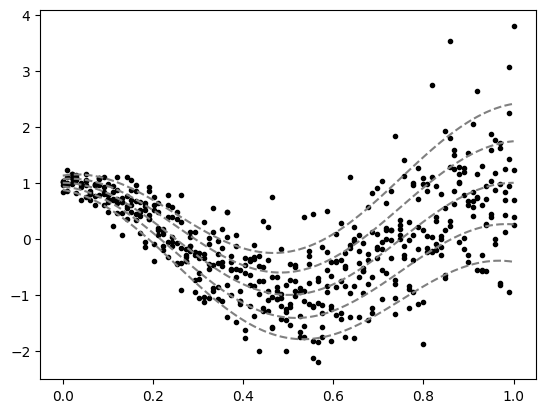

In [ ]:
plt.scatter(x.cpu(), y.cpu(), c="k", marker=".")
plt.plot(x_range.cpu(), true_quantiles.cpu(), "--", c="gray")
plt.show()

## Prior mean

In [ ]:
class PriorMean(Mean):
    def __init__(self, batch_shape=torch.Size()):
        super().__init__()
        self.batch_shape = batch_shape

    def forward(self, x):
        return mean(x).squeeze(-1).expand(*self.batch_shape, x.shape[-2])


prior_mean = PriorMean().to(device)

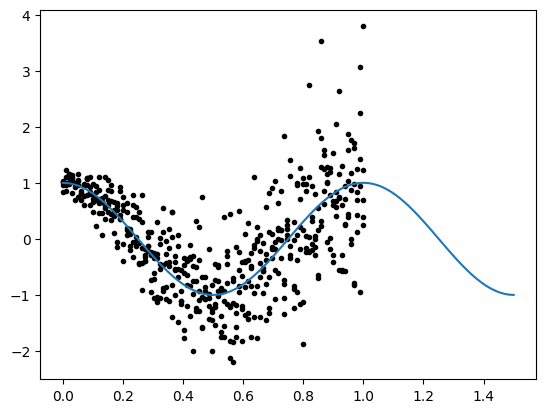

In [ ]:
plt.scatter(x.cpu(), y.cpu(), c="k", marker=".")
plt.plot(x_pred.cpu(), prior_mean(x_pred).detach().cpu())
plt.show()

## Define models and likelihoods

In [ ]:
class MyGP(CenterGapQuantileGP):
    def __init__(
        self,
        inducing_points,
        num_quantiles,
        num_lower_quantiles,
        num_latents,
    ):
        N, D = inducing_points.size()
        variational_distribution = CholeskyVariationalDistribution(
            N,
            batch_shape=torch.Size([num_latents]),
        )
        variational_strategy = CenterGapLMCVariationalStrategy(
            UnwhitenedVariationalStrategy(
                self,
                inducing_points,
                variational_distribution,
                learn_inducing_locations=True,
            ),
            num_quantiles,
            num_latents,
            num_quantiles=[num_quantiles],
            num_lower_quantiles=[num_lower_quantiles],
        )

        mean = CenterGapMean(
            PriorMean(batch_shape=torch.Size([1])),
            ConstantMean(batch_shape=torch.Size([num_latents - 1])),
        )
        covar = ScaleKernel(
            RBFKernel(ard_num_dims=D, batch_shape=torch.Size([num_latents])),
            batch_shape=torch.Size([num_latents]),
        )
        super().__init__(
            variational_strategy, mean, covar, [num_quantiles], [num_lower_quantiles]
        )


inducing_points = torch.linspace(0, 1, 10).reshape(-1, 1).to(device)
central_q_index = (q - 0.5).abs().argmin().item()
num_latents = len(q) - 2
gp = MyGP(inducing_points, len(q), central_q_index, num_latents).to(device)
likelihood = CenterGapQuantileLikelihood(q, central_q_index).to(device)

## Train

In [ ]:
gp.train()
likelihood.train()
mll = VariationalELBO(likelihood, gp, num_data=y.numel())
optimizer = torch.optim.Adam(
    list(gp.parameters()) + list(likelihood.parameters()),
    lr=0.001,
)

for _ in range(n_epochs):
    output = gp(x)
    loss = -mll(output, y)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

## Evaluate

In [ ]:
gp.eval()
with torch.no_grad():
    mean_q = gp.mean_quantiles_mc(x_pred)
    lower_q, upper_q = gp.quantile_quantiles_mc(
        x_pred, torch.tensor([0.025, 0.975]).to(device)
    )

## Plot result

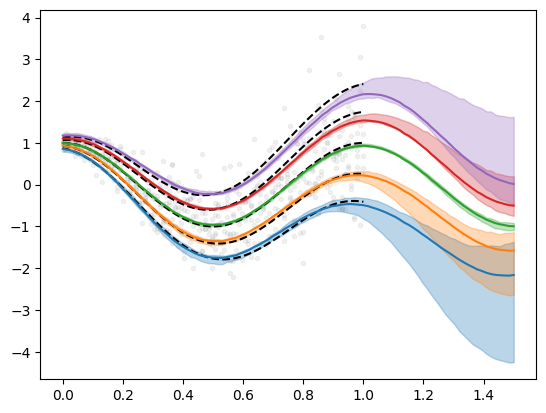

In [ ]:
colors = plt.cm.tab10.colors

plt.scatter(x.cpu(), y.cpu(), c="gray", marker=".", alpha=0.1)
plt.plot(x_range.cpu(), true_quantiles.cpu(), "--", c="k")

for i in range(len(q)):
    plt.plot(x_pred.cpu(), mean_q[:, i].cpu(), color=colors[i])
    plt.fill_between(
        x_pred.cpu().squeeze(),
        lower_q[:, i].cpu(),
        upper_q[:, i].cpu(),
        color=colors[i],
        alpha=0.3,
    )
plt.show()